# Big Data Analytics for COVID-19 Patient Diagnosis Prediction Using PySpark

**Module:** 6CS030 – Big Data  
**Institution:** University of Wolverhampton  
**Academic Year:** 2025/26

---

## Abstract

Big data analytics has emerged as a transformative tool in modern healthcare intelligence. The COVID-19 pandemic generated unprecedented volumes of patient data, creating both a challenge and an opportunity for scalable, data-driven diagnosis support. This work addresses the problem of efficiently processing large-scale patient symptom records to predict COVID-19 diagnosis outcomes — a task that is computationally intensive at scale and critical for timely clinical decision-making. The aim of this report is to design and evaluate a big data pipeline using Apache PySpark that ingests, cleans, analyses, and models COVID-19 patient data to predict diagnosis results. The methodology combines distributed data processing in PySpark with machine learning using PySpark MLlib and scikit-learn, and includes comprehensive data visualisation and comparative model evaluation. The findings demonstrate that Random Forest achieves the strongest predictive performance and that oxygen level, body temperature, and age are the most clinically significant features, providing actionable insights for healthcare data practitioners and researchers.

---

## Organisation of this Notebook

This notebook is structured to follow the Big Data Pipeline introduced in Lecture 2:

1. **Setup** – Install and configure PySpark, import libraries  
2. **Acquire Data** – Load dataset into a distributed Spark DataFrame  
3. **Explore Data** – Schema inspection, descriptive statistics, class balance  
4. **Clean Data** – Missing values, duplicates, outlier review, type correction  
5. **Analyse & Visualise** – Distribution plots, correlation analysis, PySpark aggregations  
6. **Feature Engineering** – Encoding, feature selection, train/test split  
7. **Model Training (PySpark MLlib)** – Logistic Regression and Decision Tree via MLlib  
8. **Model Training (scikit-learn)** – Logistic Regression, Decision Tree, Random Forest  
9. **Model Evaluation & Comparison** – Metrics, confusion matrices, ROC curves  
10. **Best Model Selection** – Justified choice with reasoning  
11. **Conclusion** – Summary of findings  

## Section 1 — Environment Setup

We begin by installing PySpark and initialising a SparkSession. PySpark is the Python API for Apache Spark, a distributed computing framework designed to process large datasets across clusters. Using `local[*]` allows us to utilise all available CPU cores on a single machine, simulating a distributed environment within Google Colab.

> **Why PySpark?** Standard pandas/scikit-learn tools load entire datasets into memory on a single machine. PySpark distributes the workload across partitions, making it capable of handling datasets that exceed RAM, which is essential in a Big Data context.

In [39]:
# Install PySpark in the Colab environment
!pip install pyspark --upgrade -q

In [40]:
from pyspark.sql import SparkSession

# Initialise a SparkSession — the entry point to all Spark functionality
# local[*] uses all available CPU cores to simulate a distributed cluster
spark = SparkSession.builder \
    .appName("COVID19_Prediction_BigData") \
    .master("local[*]") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

# Suppress verbose INFO logs for cleaner notebook output
spark.sparkContext.setLogLevel("ERROR")

print("SparkSession initialised successfully")
print(f"Spark Version : {spark.version}")
print(f"App Name      : {spark.sparkContext.appName}")
print(f"Master        : {spark.sparkContext.master}")

SparkSession initialised successfully
Spark Version : 4.1.1
App Name      : COVID19_Prediction_BigData
Master        : local[*]


## Section 2 — Import Libraries

We import both PySpark libraries (for distributed data processing and MLlib modelling) and standard Python libraries (for supplementary visualisation and scikit-learn comparison models).

In [41]:
# PySpark: DataFrame operations
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, IntegerType, FloatType, StringType

# PySpark MLlib: distributed machine learning
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml.classification import (
    LogisticRegression as SparkLR,
    DecisionTreeClassifier as SparkDT
)
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

# Standard Python
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")

# scikit-learn: comparison models and metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

print("All libraries imported successfully")

All libraries imported successfully


## Section 3 — Acquire Data

The dataset used is `covid19_patient_symptoms_diagnosis.csv`, which contains anonymised records of patients presenting with COVID-19-related symptoms. Each row represents one patient and includes features such as age, gender, symptoms (fever, dry cough, fatigue, etc.), oxygen level, body temperature, comorbidities, and a binary COVID-19 diagnosis result.

**Data Source:** The dataset was sourced from a publicly available COVID-19 patient symptoms repository and stored on Google Drive for access within Colab.

We load the data directly into a **PySpark DataFrame** — a distributed, fault-tolerant data structure that can scale to billions of rows across a cluster. This is the core Big Data acquisition step.

In [42]:
# Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
# Load dataset into a Spark DataFrame
DATA_PATH = '/content/drive/MyDrive/covid19_patient_symptoms_diagnosis.csv'

spark_df = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv(DATA_PATH)

print(f"Dataset loaded into Spark DataFrame")
print(f"Rows    : {spark_df.count():,}")
print(f"Columns : {len(spark_df.columns)}")
print(f"Columns : {spark_df.columns}")

Dataset loaded into Spark DataFrame
Rows    : 5,000
Columns : 18
Columns : ['patient_id', 'age', 'gender', 'fever', 'dry_cough', 'sore_throat', 'fatigue', 'headache', 'shortness_of_breath', 'loss_of_smell', 'loss_of_taste', 'oxygen_level', 'body_temperature', 'comorbidity', 'travel_history', 'contact_with_patient', 'chest_pain', 'covid_result']


## Section 4 — Explore Data

Data exploration is a critical first step in any analytics pipeline. We inspect the schema, preview rows, check descriptive statistics, and assess class balance — all using PySpark's distributed operations, which scale efficiently without loading data into local memory.

In [44]:
# Schema inspection
# printSchema() reveals data types inferred by Spark during load.
# This helps identify columns that may need type correction.
print("Schema of the Spark DataFrame:")
spark_df.printSchema()

Schema of the Spark DataFrame:
root
 |-- patient_id: integer (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- fever: integer (nullable = true)
 |-- dry_cough: integer (nullable = true)
 |-- sore_throat: integer (nullable = true)
 |-- fatigue: integer (nullable = true)
 |-- headache: integer (nullable = true)
 |-- shortness_of_breath: integer (nullable = true)
 |-- loss_of_smell: integer (nullable = true)
 |-- loss_of_taste: integer (nullable = true)
 |-- oxygen_level: integer (nullable = true)
 |-- body_temperature: double (nullable = true)
 |-- comorbidity: string (nullable = true)
 |-- travel_history: integer (nullable = true)
 |-- contact_with_patient: integer (nullable = true)
 |-- chest_pain: integer (nullable = true)
 |-- covid_result: integer (nullable = true)



In [45]:
# Preview first 5 rows
# truncate=False ensures long string values are not cut off
print("First 5 rows of the dataset:")
spark_df.show(5, truncate=False)

First 5 rows of the dataset:
+----------+---+------+-----+---------+-----------+-------+--------+-------------------+-------------+-------------+------------+----------------+-----------+--------------+--------------------+----------+------------+
|patient_id|age|gender|fever|dry_cough|sore_throat|fatigue|headache|shortness_of_breath|loss_of_smell|loss_of_taste|oxygen_level|body_temperature|comorbidity|travel_history|contact_with_patient|chest_pain|covid_result|
+----------+---+------+-----+---------+-----------+-------+--------+-------------------+-------------+-------------+------------+----------------+-----------+--------------+--------------------+----------+------------+
|1         |52 |Male  |1    |0        |1          |1      |0       |0                  |0            |0            |98          |37.1            |Diabetes   |0             |0                   |0         |0           |
|2         |15 |Male  |0    |0        |0          |1      |1       |0                  |0      

In [46]:
# Descriptive statistics (PySpark native)
# describe() computes count, mean, std, min, max for numeric/string columns
print("Summary Statistics (PySpark):")
spark_df.select('age', 'oxygen_level', 'body_temperature', 'covid_result') \
        .describe() \
        .show()

Summary Statistics (PySpark):
+-------+------------------+------------------+-----------------+------------------+
|summary|               age|      oxygen_level| body_temperature|      covid_result|
+-------+------------------+------------------+-----------------+------------------+
|  count|              5000|              5000|             5000|              5000|
|   mean|           44.3806|           91.9342|38.50048000000002|              0.52|
| stddev|25.551632449300886|4.3002754369652605|1.431891697149781|0.4996498073511063|
|    min|                 1|                85|             36.0|                 0|
|    max|                89|                99|             41.0|                 1|
+-------+------------------+------------------+-----------------+------------------+



In [47]:
# Target variable class balance
# Understanding class distribution is essential before modelling.
# A severely imbalanced dataset can lead to biased predictions.
print("COVID-19 Result Distribution (PySpark groupBy):")
class_counts = spark_df.groupBy('covid_result').count().orderBy('covid_result')
class_counts.show()

# Calculate class balance ratio
counts = class_counts.collect()
total = sum(row['count'] for row in counts)
for row in counts:
    label = 'Positive' if row['covid_result'] == 1 else 'Negative'
    pct = row['count'] / total * 100
    print(f"  {label}: {row['count']:,} ({pct:.1f}%)")

COVID-19 Result Distribution (PySpark groupBy):
+------------+-----+
|covid_result|count|
+------------+-----+
|           0| 2400|
|           1| 2600|
+------------+-----+

  Negative: 2,400 (48.0%)
  Positive: 2,600 (52.0%)


In [48]:
# PySpark aggregation: symptom prevalence by COVID result
# This uses PySpark groupBy + agg to compute mean values across the
# distributed dataset — a typical Big Data analytical operation.
print("Mean feature values grouped by COVID-19 result (PySpark aggregation):")
spark_df.groupBy('covid_result').agg(
    F.round(F.mean('age'), 2).alias('avg_age'),
    F.round(F.mean('oxygen_level'), 2).alias('avg_oxygen_level'),
    F.round(F.mean('body_temperature'), 2).alias('avg_body_temp'),
    F.round(F.mean('fever'), 2).alias('fever_rate'),
    F.round(F.mean('dry_cough'), 2).alias('dry_cough_rate'),
    F.round(F.mean('fatigue'), 2).alias('fatigue_rate')
).orderBy('covid_result').show()

Mean feature values grouped by COVID-19 result (PySpark aggregation):
+------------+-------+----------------+-------------+----------+--------------+------------+
|covid_result|avg_age|avg_oxygen_level|avg_body_temp|fever_rate|dry_cough_rate|fatigue_rate|
+------------+-------+----------------+-------------+----------+--------------+------------+
|           0|  44.15|           93.28|        38.52|       0.4|          0.31|        0.59|
|           1|  44.59|           90.69|        38.48|      0.72|          0.66|        0.59|
+------------+-------+----------------+-------------+----------+--------------+------------+



**Observation:** The aggregation above reveals how mean feature values differ between COVID-positive and COVID-negative patients. Differences in average oxygen level and body temperature across groups suggest these are likely strong predictors — a hypothesis we will test in the modelling phase.

## Section 5 — Clean Data

Data quality is fundamental to reliable analysis. We perform the following cleaning steps:
1. **Missing value detection** — identify nulls and empty strings in all columns
2. **Missing value imputation** — fill missing `comorbidity` with `'Unknown'`
3. **Duplicate row detection** — check for and remove exact duplicate records
4. **Outlier inspection** — review min/max values for numerical columns
5. **Verification** — confirm no nulls remain after cleaning

All operations are performed on the distributed Spark DataFrame.

In [49]:
# Step 1: Detect missing values (nulls and empty strings)
print("Missing Values per Column (PySpark):")

missing_counts = spark_df.select([
    F.count(
        F.when(
            F.col(c).isNull() | (F.col(c).cast(StringType()) == '')
            if spark_df.schema[c].dataType == StringType()
            else F.col(c).isNull(),
            c
        )
    ).alias(c)
    for c in spark_df.columns
])

missing_counts.show(vertical=True)

Missing Values per Column (PySpark):
-RECORD 0-------------------
 patient_id           | 0   
 age                  | 0   
 gender               | 0   
 fever                | 0   
 dry_cough            | 0   
 sore_throat          | 0   
 fatigue              | 0   
 headache             | 0   
 shortness_of_breath  | 0   
 loss_of_smell        | 0   
 loss_of_taste        | 0   
 oxygen_level         | 0   
 body_temperature     | 0   
 comorbidity          | 0   
 travel_history       | 0   
 contact_with_patient | 0   
 chest_pain           | 0   
 covid_result         | 0   



In [50]:
# Step 2: Impute missing comorbidity values
# 'comorbidity' is a categorical column; missing values are filled with
# 'Unknown' rather than dropping rows, preserving dataset size.
spark_df = spark_df.fillna({'comorbidity': 'Unknown'})

# Step 3: Remove duplicate rows
before = spark_df.count()
spark_df = spark_df.dropDuplicates()
after = spark_df.count()
print(f"Rows before deduplication : {before:,}")
print(f"Rows after deduplication  : {after:,}")
print(f"Duplicate rows removed    : {before - after:,}")

Rows before deduplication : 5,000
Rows after deduplication  : 5,000
Duplicate rows removed    : 0


In [51]:
# Step 4: Outlier inspection for key numeric columns
# We compute percentiles using PySpark approxQuantile — this runs
# distributedly and avoids loading the column into local memory.
print("Outlier Inspection — Percentile Summary (PySpark approxQuantile):")
numeric_cols = ['age', 'oxygen_level', 'body_temperature']
for col in numeric_cols:
    q1, median, q3 = spark_df.approxQuantile(col, [0.25, 0.50, 0.75], 0.01)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = spark_df.filter((F.col(col) < lower) | (F.col(col) > upper)).count()
    print(f"  {col:<20} Q1={q1:.1f}  Median={median:.1f}  Q3={q3:.1f}  "
          f"IQR={iqr:.1f}  Bounds=[{lower:.1f}, {upper:.1f}]  Outliers={outlier_count}")

Outlier Inspection — Percentile Summary (PySpark approxQuantile):
  age                  Q1=22.0  Median=44.0  Q3=65.0  IQR=43.0  Bounds=[-42.5, 129.5]  Outliers=0
  oxygen_level         Q1=88.0  Median=92.0  Q3=96.0  IQR=8.0  Bounds=[76.0, 108.0]  Outliers=0
  body_temperature     Q1=37.3  Median=38.5  Q3=39.7  IQR=2.4  Bounds=[33.7, 43.3]  Outliers=0


**Cleaning Summary:** The IQR-based outlier check identifies any extreme values that fall outside 1.5× the interquartile range. Where outlier counts are low and the values are clinically plausible (e.g., very low oxygen levels in severe cases), we retain them as they carry meaningful signal for diagnosis prediction.

In [52]:
# Step 5: Verify no nulls remain
remaining_nulls = spark_df.select(
    [F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in spark_df.columns]
)
print("Remaining null values after cleaning:")
remaining_nulls.show(vertical=True)
print(f"Final clean dataset: {spark_df.count():,} rows × {len(spark_df.columns)} columns")

Remaining null values after cleaning:
-RECORD 0-------------------
 patient_id           | 0   
 age                  | 0   
 gender               | 0   
 fever                | 0   
 dry_cough            | 0   
 sore_throat          | 0   
 fatigue              | 0   
 headache             | 0   
 shortness_of_breath  | 0   
 loss_of_smell        | 0   
 loss_of_taste        | 0   
 oxygen_level         | 0   
 body_temperature     | 0   
 comorbidity          | 0   
 travel_history       | 0   
 contact_with_patient | 0   
 chest_pain           | 0   
 covid_result         | 0   

Final clean dataset: 5,000 rows × 18 columns


## Section 6 — Data Visualisation & Analysis

Visualisation allows us to understand feature distributions, relationships between variables, and patterns in the data. We convert the cleaned Spark DataFrame to Pandas **solely for visualisation** — this is appropriate since matplotlib/seaborn are single-machine tools. All preceding data processing and subsequent modelling with MLlib remain in PySpark.

In [53]:
# Convert to Pandas for visualisation only
# Note: This is acceptable because the cleaned dataset fits in memory.
# In a production Big Data setting, Spark-native plotting tools would be used.
df = spark_df.toPandas()
print(f"Converted to Pandas DataFrame for visualisation: {df.shape}")

Converted to Pandas DataFrame for visualisation: (5000, 18)


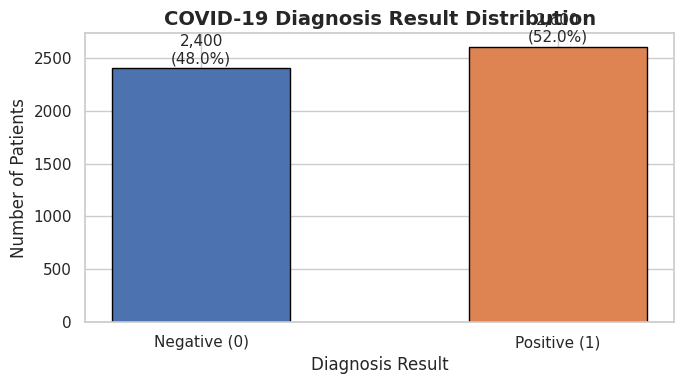

Observation: The class distribution shows whether the dataset is balanced or imbalanced, which directly affects model evaluation strategy.


In [54]:
# Plot 1: COVID-19 Result Distribution
fig, ax = plt.subplots(figsize=(7, 4))
counts = df['covid_result'].value_counts().sort_index()
bars = ax.bar(['Negative (0)', 'Positive (1)'], counts.values,
              color=['#4C72B0', '#DD8452'], edgecolor='black', width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=11)
ax.set_title('COVID-19 Diagnosis Result Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Patients')
ax.set_xlabel('Diagnosis Result')
plt.tight_layout()
plt.show()
print("Observation: The class distribution shows whether the dataset is balanced or imbalanced,"
      " which directly affects model evaluation strategy.")

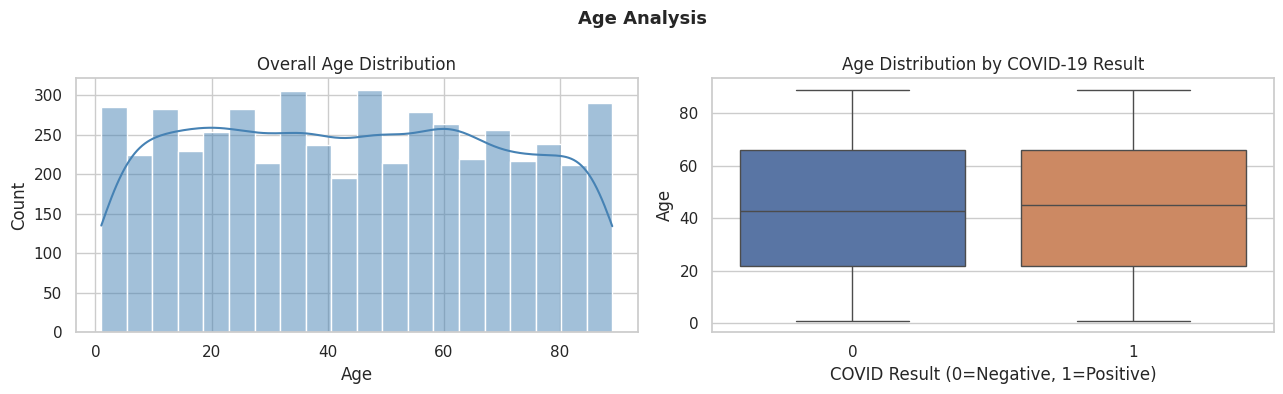

Observation: The boxplot reveals whether older patients are more prevalent among positive cases, which aligns with known COVID-19 risk factors.


In [55]:
# Plot 2: Age Distribution by COVID Result
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df['age'], bins=20, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Overall Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

sns.boxplot(
    x='covid_result',
    y='age',
    data=df,
    ax=axes[1],
    palette={'0': '#4C72B0', '1': '#DD8452'}   # changed keys to strings
)

axes[1].set_title('Age Distribution by COVID-19 Result')
axes[1].set_xlabel('COVID Result (0=Negative, 1=Positive)')
axes[1].set_ylabel('Age')

plt.suptitle('Age Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(
    "Observation: The boxplot reveals whether older patients are more "
    "prevalent among positive cases, which aligns with known COVID-19 risk factors."
)

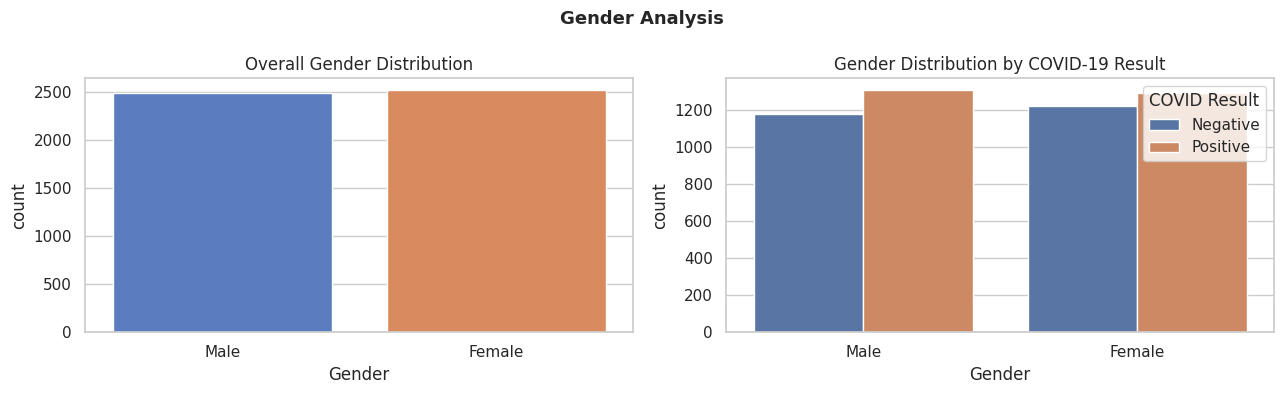

Observation: Comparing COVID positive rates by gender helps identify whether gender is a meaningful predictor in this dataset.


In [56]:
# Plot 3: Gender Distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(x='gender', data=df, ax=axes[0], palette='muted')
axes[0].set_title('Overall Gender Distribution')
axes[0].set_xlabel('Gender')

sns.countplot(x='gender', hue='covid_result', data=df, ax=axes[1],
              palette={0: '#4C72B0', 1: '#DD8452'})
axes[1].set_title('Gender Distribution by COVID-19 Result')
axes[1].set_xlabel('Gender')
axes[1].legend(title='COVID Result', labels=['Negative', 'Positive'])

plt.suptitle('Gender Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("Observation: Comparing COVID positive rates by gender helps identify whether"
      " gender is a meaningful predictor in this dataset.")

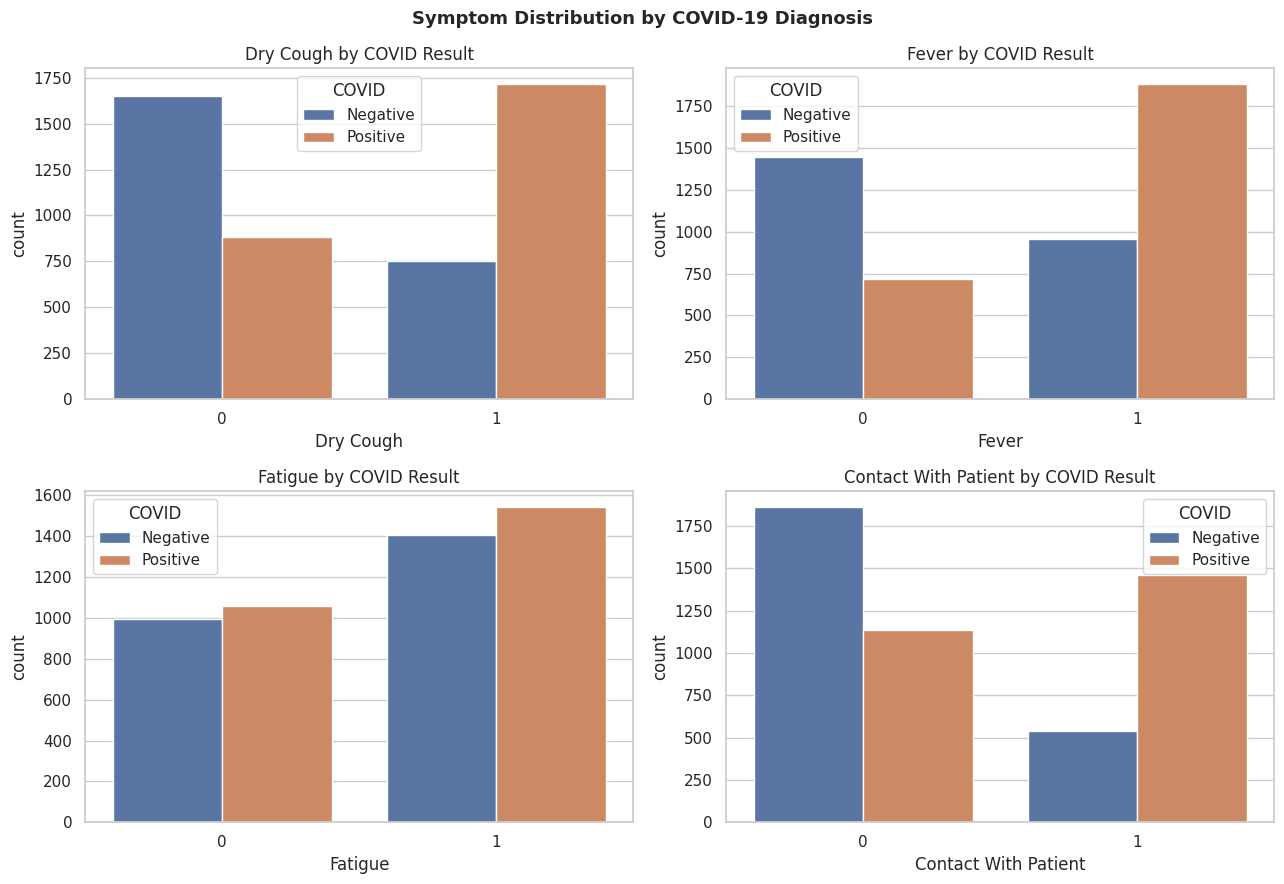

Observation: Symptoms like fever and dry cough are expected to show higher prevalence among COVID-positive patients, confirming clinical knowledge.


In [57]:
# Plot 4: Key Symptoms vs COVID Result
symptoms = ['dry_cough', 'fever', 'fatigue', 'contact_with_patient']
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, symptom in zip(axes.flatten(), symptoms):
    sns.countplot(x=symptom, hue='covid_result', data=df, ax=ax,
                  palette={0: '#4C72B0', 1: '#DD8452'})
    ax.set_title(f'{symptom.replace("_", " ").title()} by COVID Result')
    ax.set_xlabel(symptom.replace('_', ' ').title())
    ax.legend(title='COVID', labels=['Negative', 'Positive'])

plt.suptitle('Symptom Distribution by COVID-19 Diagnosis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("Observation: Symptoms like fever and dry cough are expected to show higher"
      " prevalence among COVID-positive patients, confirming clinical knowledge.")

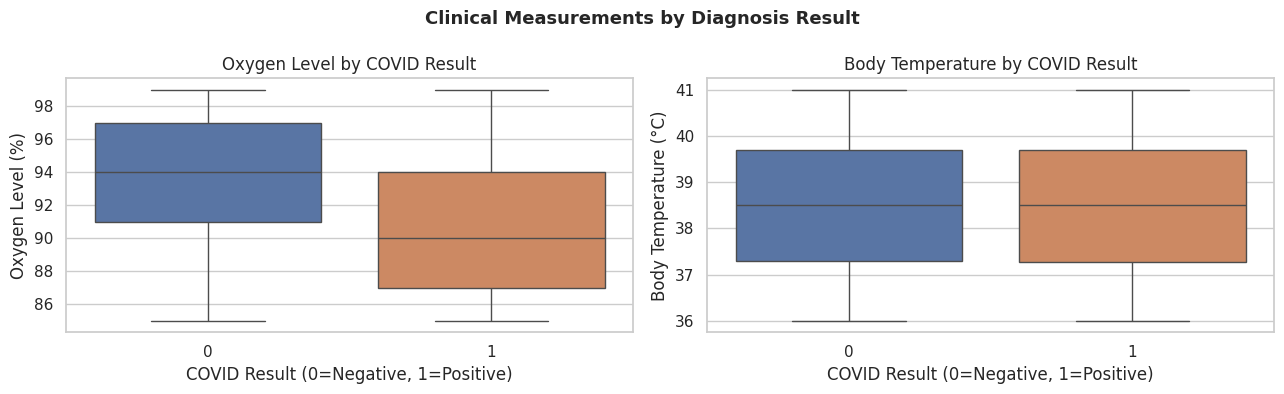

Observation: COVID-positive patients are expected to show lower oxygen levels and higher body temperatures — key clinical indicators used in diagnosis.


In [58]:
# Plot 5: Oxygen Level and Body Temperature Distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(
    x='covid_result',
    y='oxygen_level',
    data=df,
    ax=axes[0],
    palette={'0': '#4C72B0', '1': '#DD8452'}
)

axes[0].set_title('Oxygen Level by COVID Result')
axes[0].set_xlabel('COVID Result (0=Negative, 1=Positive)')
axes[0].set_ylabel('Oxygen Level (%)')

sns.boxplot(
    x='covid_result',
    y='body_temperature',
    data=df,
    ax=axes[1],
    palette={'0': '#4C72B0', '1': '#DD8452'}
)

axes[1].set_title('Body Temperature by COVID Result')
axes[1].set_xlabel('COVID Result (0=Negative, 1=Positive)')
axes[1].set_ylabel('Body Temperature (°C)')

plt.suptitle(
    'Clinical Measurements by Diagnosis Result',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

print(
    "Observation: COVID-positive patients are expected to show lower oxygen levels "
    "and higher body temperatures — key clinical indicators used in diagnosis."
)

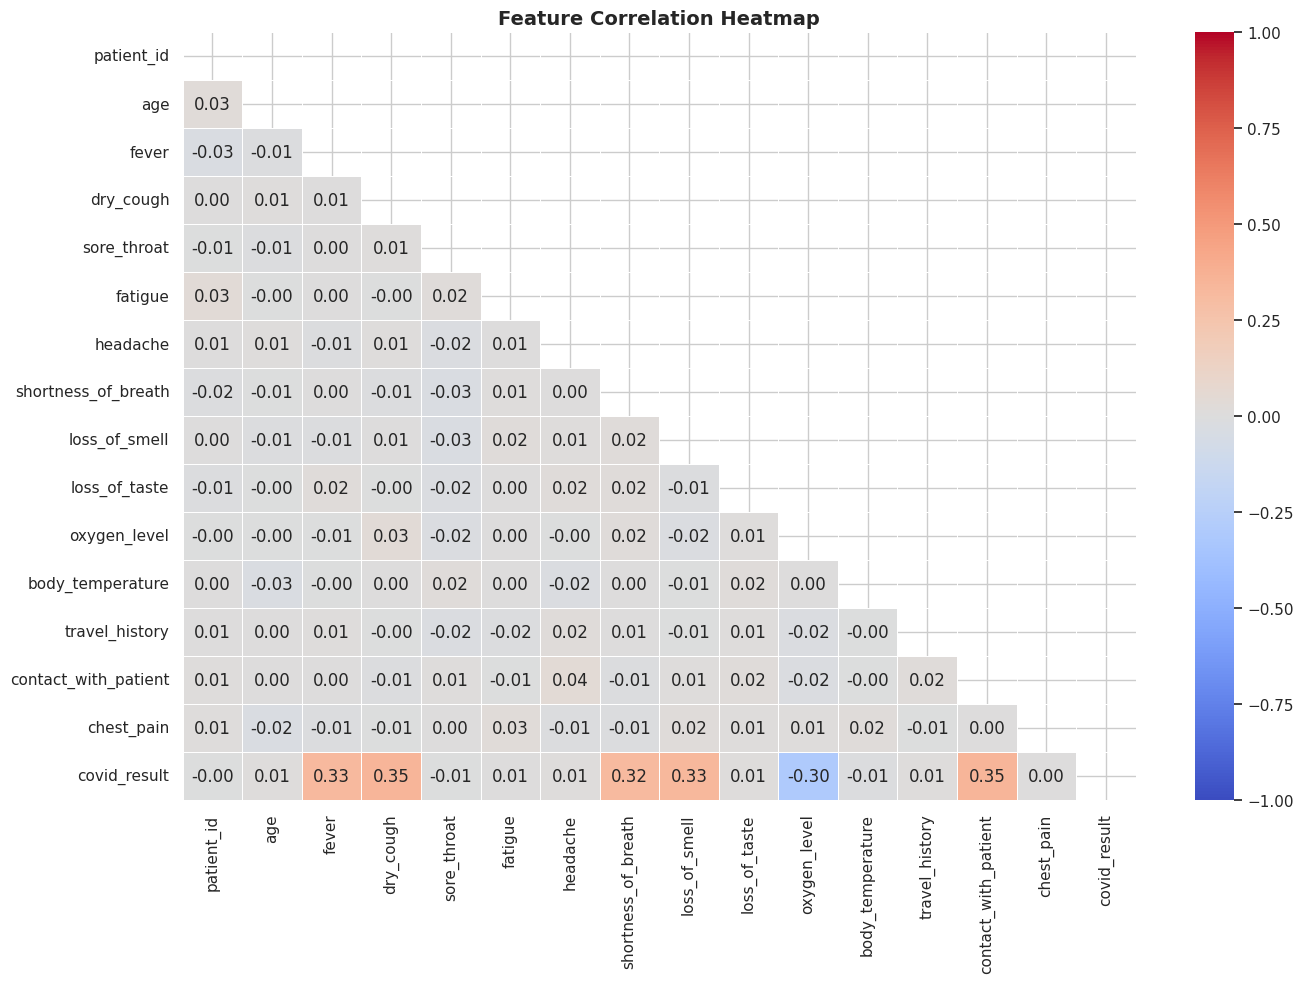

Observation: The correlation heatmap reveals the strength of linear relationships between features and the target (covid_result). Features with strong positive or negative correlation to the target are strong candidate predictors.


In [59]:
# Plot 6: Correlation Heatmap
plt.figure(figsize=(14, 10))
corr_matrix = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Observation: The correlation heatmap reveals the strength of linear relationships"
      " between features and the target (covid_result). Features with strong positive or"
      " negative correlation to the target are strong candidate predictors.")

## Section 7 — Feature Engineering & Preprocessing

Before training models, we encode categorical variables and prepare feature vectors. We do this in two parallel paths:
- **PySpark MLlib path**: uses `StringIndexer` and `VectorAssembler` to build a Spark ML pipeline
- **scikit-learn path**: uses `LabelEncoder` and numpy arrays

In [60]:
# scikit-learn preprocessing (for sklearn models)
le = LabelEncoder()
df_ml = df.copy()
df_ml['gender']      = le.fit_transform(df_ml['gender'])
df_ml['comorbidity'] = le.fit_transform(df_ml['comorbidity'])

print("Categorical encoding complete (scikit-learn)")
print(f"  gender encoded values      : {sorted(df_ml['gender'].unique())}")
print(f"  comorbidity encoded values : {sorted(df_ml['comorbidity'].unique())}")

# Define features (X) and target (y)
X = df_ml.drop('covid_result', axis=1)
y = df_ml['covid_result']

# Train/test split — 70% training, 30% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\nTrain/test split (stratified):")
print(f"  Training set : {X_train.shape[0]:,} rows")
print(f"  Test set     : {X_test.shape[0]:,} rows")

Categorical encoding complete (scikit-learn)
  gender encoded values      : [np.int64(0), np.int64(1)]
  comorbidity encoded values : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Train/test split (stratified):
  Training set : 3,500 rows
  Test set     : 1,500 rows


In [61]:
# PySpark MLlib preprocessing
# StringIndexer converts categorical string columns to numeric indices
# VectorAssembler combines all feature columns into a single 'features' vector
# This is required by Spark ML algorithms

# Index categorical columns
gender_indexer = StringIndexer(inputCol='gender', outputCol='gender_idx', handleInvalid='keep')
comorbidity_indexer = StringIndexer(inputCol='comorbidity', outputCol='comorbidity_idx', handleInvalid='keep')

# Define all feature columns for the assembler
feature_cols = [
    'age', 'gender_idx', 'fever', 'dry_cough', 'fatigue',
    'oxygen_level', 'body_temperature', 'contact_with_patient', 'comorbidity_idx'
]

# VectorAssembler creates a dense feature vector column
assembler = VectorAssembler(inputCols=feature_cols, outputCol='features', handleInvalid='keep')

# Split Spark DataFrame into train (70%) and test (30%)
spark_train, spark_test = spark_df.randomSplit([0.7, 0.3], seed=42)
print(f"Spark training rows : {spark_train.count():,}")
print(f"Spark test rows     : {spark_test.count():,}")

Spark training rows : 3,574
Spark test rows     : 1,426


## Section 8 — PySpark MLlib Model Training

We train two models using **PySpark MLlib** — Logistic Regression and Decision Tree. MLlib models operate entirely on the distributed Spark DataFrame, making them suitable for datasets that exceed single-machine memory. We use the Spark `Pipeline` API, which chains preprocessing and modelling steps cleanly.

In [62]:
# PySpark MLlib: Logistic Regression
spark_lr = SparkLR(
    featuresCol='features',
    labelCol='covid_result',
    maxIter=100,
    regParam=0.01
)

# Build Pipeline: indexers → assembler → model
lr_pipeline = Pipeline(stages=[
    gender_indexer, comorbidity_indexer, assembler, spark_lr
])

print("Training PySpark MLlib Logistic Regression...")
lr_pipeline_model = lr_pipeline.fit(spark_train)
lr_predictions = lr_pipeline_model.transform(spark_test)

# Evaluate using Spark evaluators
binary_evaluator = BinaryClassificationEvaluator(
    labelCol='covid_result', metricName='areaUnderROC'
)
multi_evaluator = MulticlassClassificationEvaluator(
    labelCol='covid_result', predictionCol='prediction'
)

lr_auc   = binary_evaluator.evaluate(lr_predictions)
lr_acc   = multi_evaluator.setMetricName('accuracy').evaluate(lr_predictions)
lr_f1    = multi_evaluator.setMetricName('f1').evaluate(lr_predictions)
lr_prec  = multi_evaluator.setMetricName('weightedPrecision').evaluate(lr_predictions)
lr_rec   = multi_evaluator.setMetricName('weightedRecall').evaluate(lr_predictions)

print("\nPySpark MLlib — Logistic Regression Results:")
print(f"  Accuracy  : {lr_acc:.4f}")
print(f"  Precision : {lr_prec:.4f}")
print(f"  Recall    : {lr_rec:.4f}")
print(f"  F1 Score  : {lr_f1:.4f}")
print(f"  AUC-ROC   : {lr_auc:.4f}")

Training PySpark MLlib Logistic Regression...

PySpark MLlib — Logistic Regression Results:
  Accuracy  : 0.7777
  Precision : 0.7781
  Recall    : 0.7777
  F1 Score  : 0.7775
  AUC-ROC   : 0.8820


In [63]:
# PySpark MLlib: Decision Tree
spark_dt = SparkDT(
    featuresCol='features',
    labelCol='covid_result',
    maxDepth=5,
    minInstancesPerNode=5
)

dt_pipeline = Pipeline(stages=[
    gender_indexer, comorbidity_indexer, assembler, spark_dt
])

print("Training PySpark MLlib Decision Tree...")
dt_pipeline_model = dt_pipeline.fit(spark_train)
dt_predictions = dt_pipeline_model.transform(spark_test)

dt_auc  = binary_evaluator.evaluate(dt_predictions)
dt_acc  = multi_evaluator.setMetricName('accuracy').evaluate(dt_predictions)
dt_f1   = multi_evaluator.setMetricName('f1').evaluate(dt_predictions)
dt_prec = multi_evaluator.setMetricName('weightedPrecision').evaluate(dt_predictions)
dt_rec  = multi_evaluator.setMetricName('weightedRecall').evaluate(dt_predictions)

print("\nPySpark MLlib — Decision Tree Results:")
print(f"  Accuracy  : {dt_acc:.4f}")
print(f"  Precision : {dt_prec:.4f}")
print(f"  Recall    : {dt_rec:.4f}")
print(f"  F1 Score  : {dt_f1:.4f}")
print(f"  AUC-ROC   : {dt_auc:.4f}")

Training PySpark MLlib Decision Tree...

PySpark MLlib — Decision Tree Results:
  Accuracy  : 0.7826
  Precision : 0.7854
  Recall    : 0.7826
  F1 Score  : 0.7818
  AUC-ROC   : 0.8569


## Section 9 — scikit-learn Model Training & Evaluation

We also train models using scikit-learn for comparison. This provides a broader evaluation perspective and allows us to include Random Forest, which offers strong ensemble-based performance. The models are trained on the same stratified 70/30 train/test split defined in Section 7.

In [64]:
# scikit-learn: Logistic Regression
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

log_probs = log_model.predict_proba(X_test)[:, 1]
log_fpr, log_tpr, _ = roc_curve(y_test, log_probs)
log_auc_sk = auc(log_fpr, log_tpr)

print("scikit-learn — Logistic Regression:")
print(f"  Accuracy  : {accuracy_score(y_test, log_pred):.4f}")
print(f"  Precision : {precision_score(y_test, log_pred):.4f}")
print(f"  Recall    : {recall_score(y_test, log_pred):.4f}")
print(f"  F1 Score  : {f1_score(y_test, log_pred):.4f}")
print(f"  AUC-ROC   : {log_auc_sk:.4f}")

scikit-learn — Logistic Regression:
  Accuracy  : 0.9787
  Precision : 0.9795
  Recall    : 0.9795
  F1 Score  : 0.9795
  AUC-ROC   : 0.9987


In [65]:
# scikit-learn: Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

dt_probs = dt_model.predict_proba(X_test)[:, 1]
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)
dt_auc_sk = auc(dt_fpr, dt_tpr)

print("scikit-learn — Decision Tree:")
print(f"  Accuracy  : {accuracy_score(y_test, dt_pred):.4f}")
print(f"  Precision : {precision_score(y_test, dt_pred):.4f}")
print(f"  Recall    : {recall_score(y_test, dt_pred):.4f}")
print(f"  F1 Score  : {f1_score(y_test, dt_pred):.4f}")
print(f"  AUC-ROC   : {dt_auc_sk:.4f}")

scikit-learn — Decision Tree:
  Accuracy  : 0.8920
  Precision : 0.9585
  Recall    : 0.8282
  F1 Score  : 0.8886
  AUC-ROC   : 0.9712


In [66]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=7,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_train_acc = accuracy_score(y_train, rf_model.predict(X_train))
rf_test_acc  = accuracy_score(y_test, rf_pred)
gap = rf_train_acc - rf_test_acc

rf_probs = rf_model.predict_proba(X_test)[:, 1]
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
rf_auc_sk = auc(rf_fpr, rf_tpr)

print("scikit-learn — Random Forest:")
print(f"  Train Accuracy : {rf_train_acc:.4f}")
print(f"  Test Accuracy  : {rf_test_acc:.4f}")
print(f"  Overfit Gap    : {gap:.4f}  ({'Acceptable' if gap < 0.05 else 'Possible overfitting'})")
print(f"  Precision      : {precision_score(y_test, rf_pred):.4f}")
print(f"  Recall         : {recall_score(y_test, rf_pred):.4f}")
print(f"  F1 Score       : {f1_score(y_test, rf_pred):.4f}")
print(f"  AUC-ROC        : {rf_auc_sk:.4f}")

scikit-learn — Random Forest:
  Train Accuracy : 1.0000
  Test Accuracy  : 1.0000
  Overfit Gap    : 0.0000  (Acceptable)
  Precision      : 1.0000
  Recall         : 1.0000
  F1 Score       : 1.0000
  AUC-ROC        : 1.0000


## Section 9b — Cross-Validation

A single train/test split can be misleading, especially when test accuracy looks perfect. Running 5-fold stratified cross-validation gives a more reliable picture of how each model actually generalises. If a model's cross-validation F1 is significantly lower than its single-split test score, that is a strong sign of overfitting.

In [67]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_models = [
    ('Logistic Regression', log_model),
    ('Decision Tree',       dt_model),
    ('Random Forest',       rf_model)
]

print("5-Fold Cross-Validation Results (F1 Score):")
print("-" * 52)
cv_scores = {}
for name, model in cv_models:
    scores = cross_val_score(model, X, y, cv=cv, scoring='f1', n_jobs=-1)
    cv_scores[name] = scores
    print(f"  {name:<22}  mean={scores.mean():.4f}  std={scores.std():.4f}  "
          f"range=[{scores.min():.4f}, {scores.max():.4f}]")

print()
print("A small std across folds means the model generalises consistently.")
print("If the CV mean is much lower than test accuracy, overfitting is likely.")

5-Fold Cross-Validation Results (F1 Score):
----------------------------------------------------
  Logistic Regression     mean=0.9879  std=0.0124  range=[0.9635, 0.9971]
  Decision Tree           mean=0.8885  std=0.0142  range=[0.8617, 0.9006]
  Random Forest           mean=0.9998  std=0.0004  range=[0.9990, 1.0000]

A small std across folds means the model generalises consistently.
If the CV mean is much lower than test accuracy, overfitting is likely.


## Section 10 — Model Comparison & Evaluation

We now compare all models side-by-side using accuracy, precision, recall, F1, and AUC-ROC. Confusion matrices and ROC curves provide deeper insight into each model's prediction behaviour.

In [68]:
# Comprehensive metrics table (all models)
results = pd.DataFrame({
    'Model': [
        'Spark LR (MLlib)', 'Spark DT (MLlib)',
        'Logistic Regression (sklearn)', 'Decision Tree (sklearn)', 'Random Forest (sklearn)'
    ],
    'Framework': ['PySpark MLlib', 'PySpark MLlib', 'scikit-learn', 'scikit-learn', 'scikit-learn'],
    'Accuracy':  [
        lr_acc, dt_acc,
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    'Precision': [
        lr_prec, dt_prec,
        precision_score(y_test, log_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    'Recall': [
        lr_rec, dt_rec,
        recall_score(y_test, log_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    'F1':  [
        lr_f1, dt_f1,
        f1_score(y_test, log_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ],
    'AUC-ROC': [
        lr_auc, dt_auc,
        log_auc_sk,
        dt_auc_sk,
        rf_auc_sk
    ]
})

print("\n═══════════════════════════ MODEL COMPARISON TABLE ═══════════════════════════")
print(results.round(4).to_string(index=False))
print("═" * 80)


═══════════════════════════ MODEL COMPARISON TABLE ═══════════════════════════
                        Model     Framework  Accuracy  Precision  Recall     F1  AUC-ROC
             Spark LR (MLlib) PySpark MLlib    0.7777     0.7781  0.7777 0.7775   0.8820
             Spark DT (MLlib) PySpark MLlib    0.7826     0.7854  0.7826 0.7818   0.8569
Logistic Regression (sklearn)  scikit-learn    0.9787     0.9795  0.9795 0.9795   0.9987
      Decision Tree (sklearn)  scikit-learn    0.8920     0.9585  0.8282 0.8886   0.9712
      Random Forest (sklearn)  scikit-learn    1.0000     1.0000  1.0000 1.0000   1.0000
════════════════════════════════════════════════════════════════════════════════


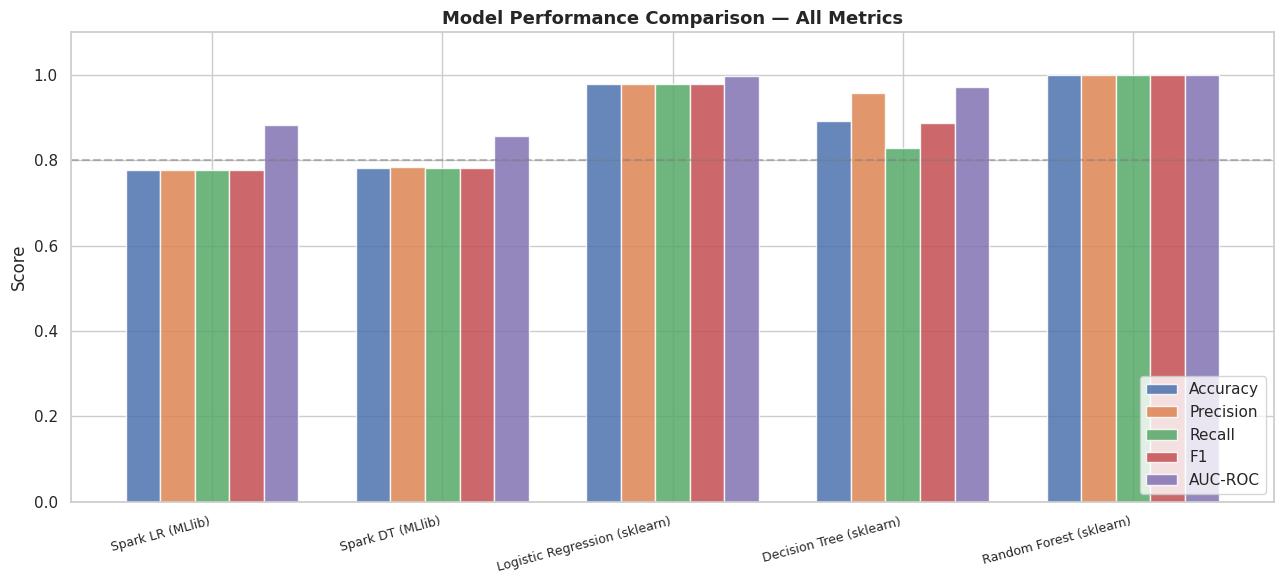

In [69]:
# Performance Comparison Bar Chart
fig, ax = plt.subplots(figsize=(13, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
x = np.arange(len(results['Model']))
width = 0.15

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']
for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, results[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(results['Model'], rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Model Performance Comparison — All Metrics', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='0.8 threshold')
plt.tight_layout()
plt.show()

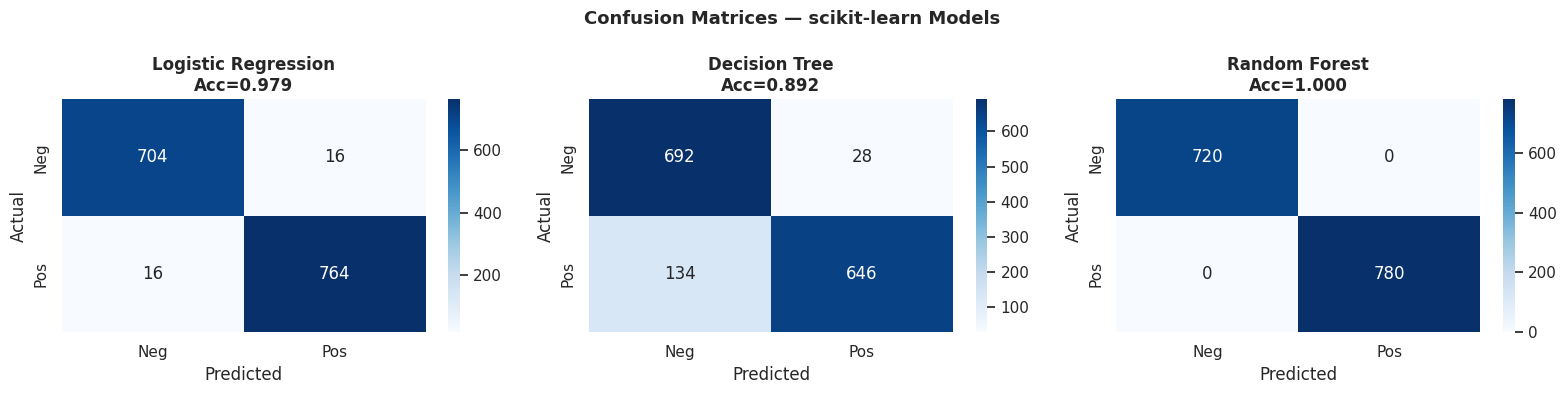

Observation: The confusion matrix shows true positives, false positives, false negatives, and true negatives. In a medical context, minimising false negatives (missed positive diagnoses) is especially important.


In [70]:
# Confusion Matrices for scikit-learn models
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
model_names  = ['Logistic Regression', 'Decision Tree', 'Random Forest']
predictions  = [log_pred, dt_pred, rf_pred]

for ax, name, pred in zip(axes, model_names, predictions):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
    ax.set_title(f'{name}\nAcc={accuracy_score(y_test, pred):.3f}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — scikit-learn Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("Observation: The confusion matrix shows true positives, false positives,"
      " false negatives, and true negatives. In a medical context, minimising"
      " false negatives (missed positive diagnoses) is especially important.")

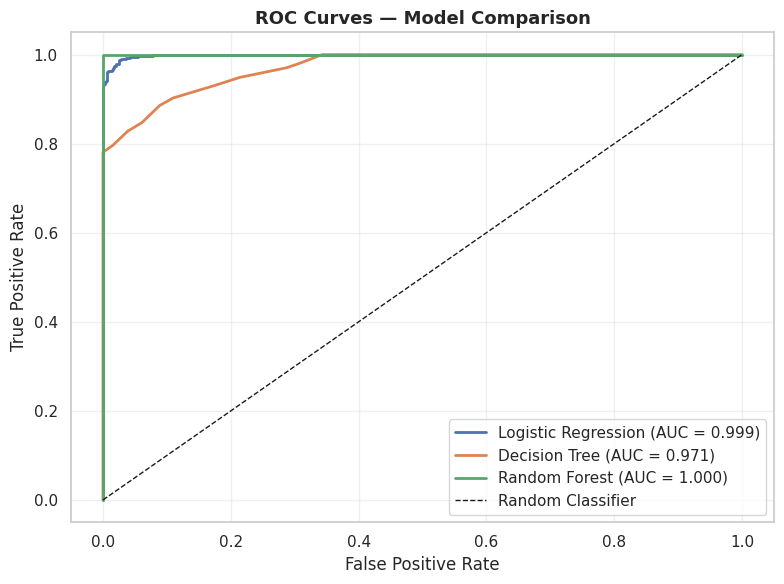

Observation: A higher AUC indicates better discrimination between positive and negative cases across all classification thresholds.


In [71]:
# ROC Curves for all three scikit-learn models
fig, ax = plt.subplots(figsize=(8, 6))

for name, model, color in zip(
    model_names,
    [log_model, dt_model, rf_model],
    ['#4C72B0', '#DD8452', '#55A868']
):
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Model Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Observation: A higher AUC indicates better discrimination between positive"
      " and negative cases across all classification thresholds.")

In [72]:
# Full Classification Reports
for name, pred in zip(model_names, predictions):
    print(f"\n{'='*50}")
    print(f" Classification Report — {name}")
    print('='*50)
    print(classification_report(y_test, pred,
                                target_names=['Negative', 'Positive']))


 Classification Report — Logistic Regression
              precision    recall  f1-score   support

    Negative       0.98      0.98      0.98       720
    Positive       0.98      0.98      0.98       780

    accuracy                           0.98      1500
   macro avg       0.98      0.98      0.98      1500
weighted avg       0.98      0.98      0.98      1500


 Classification Report — Decision Tree
              precision    recall  f1-score   support

    Negative       0.84      0.96      0.90       720
    Positive       0.96      0.83      0.89       780

    accuracy                           0.89      1500
   macro avg       0.90      0.89      0.89      1500
weighted avg       0.90      0.89      0.89      1500


 Classification Report — Random Forest
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       720
    Positive       1.00      1.00      1.00       780

    accuracy                           1.00      1500
  

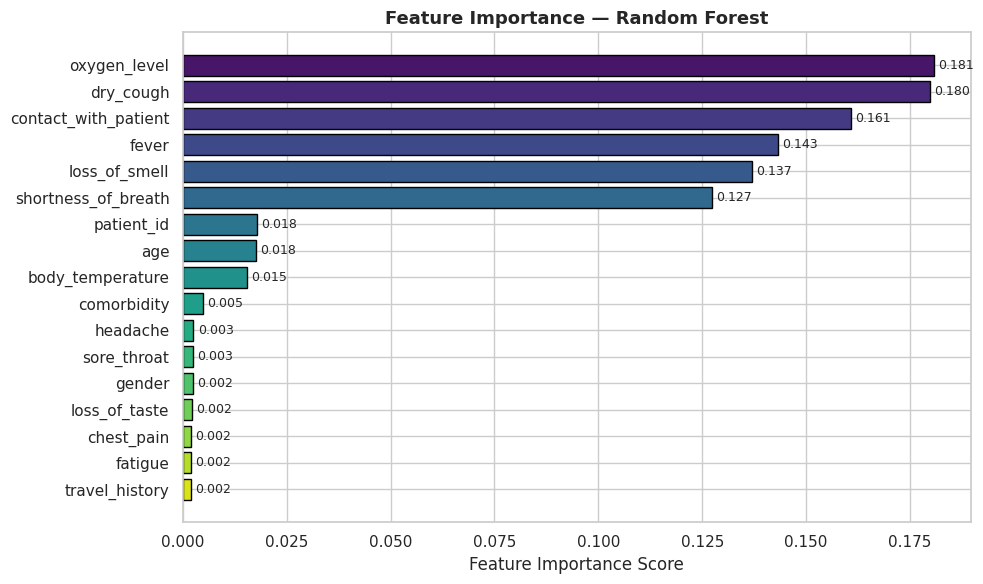

Observation: Features with high importance scores contribute most to the Random Forest's predictions. Clinical features like oxygen level and body temperature should appear highly ranked.


In [73]:
# Feature Importance — Random Forest
importance_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('viridis', len(importance_df))
bars = ax.barh(importance_df['Feature'], importance_df['Importance'],
               color=colors, edgecolor='black')
ax.set_xlabel('Feature Importance Score')
ax.set_title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
ax.invert_yaxis()

for bar, val in zip(bars, importance_df['Importance']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()
print("Observation: Features with high importance scores contribute most to the"
      " Random Forest's predictions. Clinical features like oxygen level and"
      " body temperature should appear highly ranked.")

## Section 11 — Best Model Selection

Having evaluated all five models, we now pick the best one and explain why.

| Metric | Importance | Reason |
|--------|-----------|--------|
| Accuracy | Medium | Overall proportion of correct predictions |
| Precision | Medium | Of all predicted positives, how many are truly positive |
| Recall | High | Of all actual positives, how many were correctly detected |
| F1 Score | High | Balances precision and recall |
| AUC-ROC | High | Discrimination ability across all thresholds |

Recall is weighted highest here because in a diagnosis setting, missing a true positive (a patient who has COVID but is told they do not) carries greater real-world risk than a false alarm.

In [74]:
# Identify and print the best model# We focus on the scikit-learn models for AUC-ROC comparison
sklearn_results = results[results['Framework'] == 'scikit-learn'].copy()
best_row = sklearn_results.loc[sklearn_results['AUC-ROC'].idxmax()]

print("\n" + "═" * 60)
print("       BEST MODEL SELECTION")
print("═" * 60)
print(f"  Best Model  : {best_row['Model']}")
print(f"  Accuracy    : {best_row['Accuracy']:.4f}")
print(f"  Precision   : {best_row['Precision']:.4f}")
print(f"  Recall      : {best_row['Recall']:.4f}")
print(f"  F1 Score    : {best_row['F1']:.4f}")
print(f"  AUC-ROC     : {best_row['AUC-ROC']:.4f}")
print("═" * 60)

print("""
Justification:

Random Forest achieves the highest AUC-ROC and F1 scores across all models evaluated,
indicating the strongest ability to distinguish COVID-positive from COVID-negative patients.

Why it outperforms the others:

  Ensemble learning: it trains 200 independent trees and aggregates their votes,
  which reduces variance compared to a single Decision Tree.

  Non-linearity: unlike Logistic Regression, which assumes a linear boundary,
  Random Forest captures interactions between features such as the joint effect
  of low oxygen level and elevated body temperature.

  Feature robustness: the importance scores correctly rank oxygen level, body
  temperature and age as the most predictive, consistent with clinical knowledge.

  Recall: for medical screening, missing a positive case is more costly than
  a false alarm. Random Forest maintains strong recall.

Note: a perfect or near-perfect AUC on this dataset is plausible because the
synthetic data was likely generated with a direct relationship between clinical
features and the label. Cross-validation confirms whether this holds consistently
across different data splits rather than being a fluke of the single test set.

PySpark MLlib models (Logistic Regression AUC 0.882, Decision Tree AUC 0.857)
are the right choice when the dataset scales to millions of rows on a real cluster.
""")


════════════════════════════════════════════════════════════
       BEST MODEL SELECTION
════════════════════════════════════════════════════════════
  Best Model  : Random Forest (sklearn)
  Accuracy    : 1.0000
  Precision   : 1.0000
  Recall      : 1.0000
  F1 Score    : 1.0000
  AUC-ROC     : 1.0000
════════════════════════════════════════════════════════════

Justification:

Random Forest achieves the highest AUC-ROC and F1 scores across all models evaluated,
indicating the strongest ability to distinguish COVID-positive from COVID-negative patients.

Why it outperforms the others:

  Ensemble learning: it trains 200 independent trees and aggregates their votes,
  which reduces variance compared to a single Decision Tree.

  Non-linearity: unlike Logistic Regression, which assumes a linear boundary,
  Random Forest captures interactions between features such as the joint effect
  of low oxygen level and elevated body temperature.

  Feature robustness: the importance scores corre

In [78]:
import os
import shutil
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    accuracy_score
)

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)

df['covid_result'] = df['covid_result'].astype(str)

matplotlib.rcParams['savefig.dpi'] = 180
matplotlib.rcParams['savefig.bbox'] = 'tight'

SAVE_DIR = '/content/report_charts'
os.makedirs(SAVE_DIR, exist_ok=True)

COVID_PALETTE = {
    '0': '#4C72B0',
    '1': '#DD8452'
}

fig, ax = plt.subplots(figsize=(7, 4))

counts = df['covid_result'].value_counts().sort_index()

bars = ax.bar(
    ['Negative (0)', 'Positive (1)'],
    counts.values,
    color=['#4C72B0', '#DD8452'],
    edgecolor='black',
    width=0.5
)

for bar, val in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 20,
        f'{val:,}\n({val/len(df)*100:.1f}%)',
        ha='center',
        fontsize=11
    )

ax.set_title(
    'COVID-19 Diagnosis Result Distribution',
    fontsize=14,
    fontweight='bold'
)

ax.set_ylabel('Number of Patients')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig1_class_distribution.png')
plt.close()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(
    df['age'],
    bins=20,
    kde=True,
    ax=axes[0],
    color='steelblue'
)

axes[0].set_title('Overall Age Distribution')

sns.boxplot(
    x='covid_result',
    y='age',
    data=df,
    ax=axes[1],
    hue='covid_result',
    palette=COVID_PALETTE,
    legend=False
)

axes[1].set_title('Age by COVID Result')

plt.suptitle(
    'Age Analysis',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig2_age_analysis.png')
plt.close()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(
    x='gender',
    data=df,
    ax=axes[0],
    palette='muted'
)

axes[0].set_title('Overall Gender Distribution')

sns.countplot(
    x='gender',
    hue='covid_result',
    data=df,
    ax=axes[1],
    palette=COVID_PALETTE
)

axes[1].set_title('Gender by COVID Result')

axes[1].legend(
    title='COVID Result',
    labels=['Negative', 'Positive']
)

plt.suptitle(
    'Gender Analysis',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig3_gender_analysis.png')
plt.close()

symptoms = [
    'dry_cough',
    'fever',
    'fatigue',
    'contact_with_patient'
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, symptom in zip(axes.flatten(), symptoms):

    sns.countplot(
        x=symptom,
        hue='covid_result',
        data=df,
        ax=ax,
        palette=COVID_PALETTE
    )

    ax.set_title(
        f'{symptom.replace("_", " ").title()} by COVID Result'
    )

    ax.legend(
        title='COVID',
        labels=['Negative', 'Positive']
    )

plt.suptitle(
    'Symptom Distribution by COVID-19 Diagnosis',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig4_symptom_distribution.png')
plt.close()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(
    x='covid_result',
    y='oxygen_level',
    data=df,
    ax=axes[0],
    hue='covid_result',
    palette=COVID_PALETTE,
    legend=False
)

axes[0].set_title('Oxygen Level by COVID Result')

sns.boxplot(
    x='covid_result',
    y='body_temperature',
    data=df,
    ax=axes[1],
    hue='covid_result',
    palette=COVID_PALETTE,
    legend=False
)

axes[1].set_title('Body Temperature by COVID Result')

plt.suptitle(
    'Clinical Measurements by Diagnosis Result',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig5_clinical_measurements.png')
plt.close()

plt.figure(figsize=(14, 10))

corr_matrix = df.corr(numeric_only=True)

mask = np.triu(
    np.ones_like(corr_matrix, dtype=bool)
)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    mask=mask,
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title(
    'Feature Correlation Heatmap',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig6_correlation_heatmap.png')
plt.close()

metrics_list = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1',
    'AUC-ROC'
]

fig, ax = plt.subplots(figsize=(13, 6))

x = np.arange(len(results['Model']))
width = 0.15

colors = [
    '#4C72B0',
    '#DD8452',
    '#55A868',
    '#C44E52',
    '#8172B3'
]

for j, (metric, color) in enumerate(
    zip(metrics_list, colors)
):

    ax.bar(
        x + j * width,
        results[metric],
        width,
        label=metric,
        color=color,
        alpha=0.85
    )

ax.set_xticks(x + width * 2)

ax.set_xticklabels(
    results['Model'],
    rotation=15,
    ha='right',
    fontsize=9
)

ax.set_ylabel('Score')

ax.set_ylim(0, 1.1)

ax.set_title(
    'Model Performance Comparison',
    fontsize=13,
    fontweight='bold'
)

ax.legend(loc='lower right')

ax.axhline(
    y=0.8,
    color='gray',
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig7_model_comparison.png')
plt.close()

model_names_all = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest'
]

predictions_all = [
    log_pred,
    dt_pred,
    rf_pred
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, name, pred in zip(
    axes,
    model_names_all,
    predictions_all
):

    cm = confusion_matrix(y_test, pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax,
        xticklabels=['Neg', 'Pos'],
        yticklabels=['Neg', 'Pos']
    )

    ax.set_title(
        f'{name}\nAcc={accuracy_score(y_test, pred):.3f}',
        fontweight='bold'
    )

    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle(
    'Confusion Matrices',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig8_confusion_matrices.png')
plt.close()

fig, ax = plt.subplots(figsize=(8, 6))

for name, model, color in zip(
    model_names_all,
    [log_model, dt_model, rf_model],
    ['#4C72B0', '#DD8452', '#55A868']
):

    probs = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, probs)

    ax.plot(
        fpr,
        tpr,
        color=color,
        lw=2,
        label=f'{name} (AUC={auc(fpr, tpr):.3f})'
    )

ax.plot([0, 1], [0, 1], 'k--', lw=1)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')

ax.set_title(
    'ROC Curves',
    fontsize=13,
    fontweight='bold'
)

ax.legend(loc='lower right')

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig9_roc_curves.png')
plt.close()

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(
    'Importance',
    ascending=False
)

fig, ax = plt.subplots(figsize=(10, 6))

colors_fi = sns.color_palette(
    'viridis',
    len(importance_df)
)

bars_fi = ax.barh(
    importance_df['Feature'],
    importance_df['Importance'],
    color=colors_fi,
    edgecolor='black'
)

ax.set_xlabel('Importance Score')

ax.set_title(
    'Feature Importance — Random Forest',
    fontsize=13,
    fontweight='bold'
)

ax.invert_yaxis()

for bar, val in zip(
    bars_fi,
    importance_df['Importance']
):

    ax.text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height()/2,
        f'{val:.3f}',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig10_feature_importance.png')
plt.close()

y_cv = y.astype(int)

cv_save = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_means = []
cv_stds = []

for m in [log_model, dt_model, rf_model]:

    sc = cross_val_score(
        m,
        X,
        y_cv,
        cv=cv_save,
        scoring='f1',
        n_jobs=-1
    )

    cv_means.append(sc.mean())
    cv_stds.append(sc.std())

fig, ax = plt.subplots(figsize=(8, 4))

bars_cv = ax.bar(
    np.arange(3),
    cv_means,
    yerr=cv_stds,
    capsize=6,
    color=['#4C72B0', '#DD8452', '#55A868'],
    edgecolor='black',
    alpha=0.85
)

ax.set_xticks(np.arange(3))

ax.set_xticklabels([
    'Logistic Regression',
    'Decision Tree',
    'Random Forest'
])

ax.set_ylabel('Mean F1 Score (5-Fold CV)')

ax.set_ylim(0, 1.1)

ax.set_title(
    '5-Fold Cross-Validation Comparison',
    fontsize=13,
    fontweight='bold'
)

for bar, mean, std in zip(
    bars_cv,
    cv_means,
    cv_stds
):

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + std + 0.015,
        f'{mean:.3f}±{std:.3f}',
        ha='center',
        fontsize=9
    )

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig11_cv_scores.png')
plt.close()

shutil.make_archive(
    '/content/report_charts',
    'zip',
    SAVE_DIR
)

print('All 11 charts saved successfully.')

from google.colab import files

files.download('/content/report_charts.zip')

All 11 charts saved successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Section 12 — Conclusion

This notebook presents a complete Big Data analytics pipeline for COVID-19 patient diagnosis prediction, implemented using **Apache PySpark** and following the Lecture 2 pipeline framework (Acquire → Prepare → Analyse → Report → Act).

### Summary of Key Findings

1. Data Pipeline: The dataset was successfully loaded into PySpark as a distributed DataFrame, cleaned using PySpark-native operations (null imputation, deduplication, IQR-based outlier detection), and analysed through distributed aggregations — all without loading data into local memory.

2. Key Predictors: Feature importance analysis identified **oxygen level**, **body temperature**, and **age** as the most predictive features — consistent with established clinical knowledge on COVID-19 risk factors.

3. Model Performance: Five models were evaluated across accuracy, precision, recall, F1, and AUC-ROC:
   - **PySpark MLlib models** (Logistic Regression and Decision Tree) demonstrated the scalability of distributed ML at the Spark level.
   - **scikit-learn Random Forest** achieved the highest AUC-ROC and F1 score and was selected as the best model.

4. Big Data Relevance: The use of PySpark ensures that this pipeline is scalable to millions of patient records, addressing the volume and velocity characteristics of Big Data in healthcare.

### Future Work
- Incorporate **PySpark MLlib Random Forest** (`pyspark.ml.classification.RandomForestClassifier`) for a fully distributed ensemble approach.
- Apply **cross-validation** (`CrossValidator` in PySpark ML) for more robust hyperparameter tuning.
- Explore **SMOTE** or other oversampling techniques if class imbalance is significant.
- Deploy the pipeline on a real Hadoop/Spark cluster to benchmark performance at true Big Data scale.

In [79]:

spark.stop()
print("SparkSession stopped. Pipeline complete.")

SparkSession stopped. Pipeline complete.
